In [22]:
import pandas as pd
import json
from typing import TypedDict, Dict, Any
from langgraph.graph import StateGraph, END
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq

In [23]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['GROQ_API_KEY']=""

In [24]:
class State(TypedDict):
    invoice_file: str
    bank_file: str
    journal_file: str
    draft_journals: str
    validation_feedback: str
    is_valid: bool
    iteration: int

In [25]:
def generate_draft_journals(state:State):
    print('===============agent1==================')

    df_invoices = pd.read_csv(state["invoice_file"])
    df_bank = pd.read_csv(state["bank_file"])

    df_invoices['Inv Num'] = df_invoices['Inv Num'].astype(str)

    journals = []

    for index, row in df_bank.iterrows():
        inv_nums = [inv.strip() for inv in str(row['Description']).split(',')]

        matched_invoices = df_invoices[df_invoices['Inv Num'].isin(inv_nums)]

        expected_amount = matched_invoices['Amount INR'].sum()
        actual_received = row['Amount CR']

        conversion_fee = expected_amount - actual_received

        journals.append({
            "Date": row['Date'],
            "Description": "Conversion Fee",
            "Amount CR": conversion_fee
        })

    draft_df = pd.DataFrame(journals)

    return {"draft_journals": draft_df.to_json(orient="records")}

In [26]:
def audit_agent(state:State):
    print('===============agent2==================')

    llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    )

    df_invoices = pd.read_csv(state["invoice_file"])
    df_bank = pd.read_csv(state["bank_file"])

    system_prompt = """You are an expert Financial Auditor. Your job is to validate a draft Journal Statement for Conversion Fees.

    RULES FOR CONVERSION FEE:
    1. Match the Bank Transaction 'Description' to the Invoice 'Inv Num'.
    2. Sum the 'Amount INR' for those invoices (Expected Amount).
    3. Subtract the Bank's 'Amount CR' (Received Amount) from the Expected Amount.
    4. The difference is the Conversion Fee.

    Reply in strict JSON format:
    {
        "is_valid": true/false,
        "reasoning": "Step by step math showing why it is correct or incorrect."
    }
    """

    human_prompt = f"""
    Input Invoices:
    {df_invoices.to_string()}

    Input Bank Statements:
    {df_bank.to_string()}

    Proposed Draft Journals:
    {state["draft_journals"]}

    Audit the proposed journals. Are the amounts correct based on the rules?
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=human_prompt)
    ]

    response = llm.invoke(messages)
    try:
        clean_json = response.content.replace("```json", "").replace("```", "").strip()
        result = json.loads(clean_json)
        is_valid = result.get("is_valid", False)
        feedback = result.get("reasoning", "No reasoning provided.")
    except Exception as e:
        is_valid = False
        feedback = f"Failed to parse LLM response. Error: {str(e)}"

    print(f"auditor conclusion: Valid = {is_valid}\nReasoning: {feedback}")

    return {
        "is_valid": is_valid,
        "validation_feedback": feedback,
        "iteration": state.get("iteration", 0) + 1
    }

In [27]:
def save_approved_journals(state:State):

    print("--- [SYSTEM] SAVING FINAL JOURNALS ---")
    draft_df = pd.read_json(state["draft_journals"], orient="records")
    draft_df.to_csv(state["journal_file"], index=False)
    print(f"Success! Saved to {state['journal_file']}")
    return state

In [28]:
# Initialize Graph
workflow = StateGraph(State)

# Add Nodes
workflow.add_node("maker", generate_draft_journals)
workflow.add_node("auditor", audit_agent)
workflow.add_node("save", save_approved_journals)

# Define Routing Logic
def route_validation(state: State):
    if state["is_valid"]:
        return "save"
    elif state["iteration"] >= 2:
        print("Max iterations reached. Ending workflow for manual review.")
        return END
    else:
        print("Validation failed. Routing back to Maker...")
        return "maker"

# Define Edges
workflow.set_entry_point("maker")
workflow.add_edge("maker", "auditor")
workflow.add_conditional_edges(
    "auditor",
    route_validation,
    {
        "save": "save",
        "maker": "maker",
        END: END
    }
)
workflow.add_edge("save", END)

app = workflow.compile()


In [29]:
initial_state = {
      "invoice_file": "./invoice_transactions.csv",
      "bank_file": "./bank_transactions.csv",
      "journal_file": "journals.csv",
      "iteration": 0,
      "is_valid": False
}
app.invoke(initial_state)

===============agent1==================
===============agent2==================
auditor conclusion: Valid = True
Reasoning: Step-by-step calculation:

1. 14‑05‑2026: Invoice 1001 → Expected INR = 16600. Bank CR = 16400. Conversion fee = 16600 – 16400 = 200. Draft journal shows 200.
2. 16‑05‑2026: Invoices 1002 & 1003 → Expected INR = 12450 + 24900 = 37350. Bank CR = 36800. Conversion fee = 37350 – 36800 = 550. Draft journal shows 550.
3. 18‑05‑2026: Invoice 1004 → Expected INR = 4150. Bank CR = 4050. Conversion fee = 4150 – 4050 = 100. Draft journal shows 100.
4. 20‑05‑2026: Invoice 1005 → Expected INR = 41500. Bank CR = 40850. Conversion fee = 41500 – 40850 = 650. Draft journal shows 650.

All draft amounts match the calculated conversion fees, so the journals are valid.
--- [SYSTEM] SAVING FINAL JOURNALS ---
Success! Saved to journals.csv


/tmp/ipykernel_7118/564815639.py:4: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  draft_df = pd.read_json(state["draft_journals"], orient="records")


{'invoice_file': './invoice_transactions.csv',
 'bank_file': './bank_transactions.csv',
 'journal_file': 'journals.csv',
 'draft_journals': '[{"Date":"14-05-2026","Description":"Conversion Fee","Amount CR":200},{"Date":"16-05-2026","Description":"Conversion Fee","Amount CR":550},{"Date":"18-05-2026","Description":"Conversion Fee","Amount CR":100},{"Date":"20-05-2026","Description":"Conversion Fee","Amount CR":650}]',
 'validation_feedback': 'Step-by-step calculation:\n\n1. 14‑05‑2026: Invoice 1001 → Expected INR = 16600. Bank CR = 16400. Conversion fee = 16600 – 16400 = 200. Draft journal shows 200.\n2. 16‑05‑2026: Invoices 1002 & 1003 → Expected INR = 12450 + 24900 = 37350. Bank CR = 36800. Conversion fee = 37350 – 36800 = 550. Draft journal shows 550.\n3. 18‑05‑2026: Invoice 1004 → Expected INR = 4150. Bank CR = 4050. Conversion fee = 4150 – 4050 = 100. Draft journal shows 100.\n4. 20‑05‑2026: Invoice 1005 → Expected INR = 41500. Bank CR = 40850. Conversion fee = 41500 – 40850 = 650.

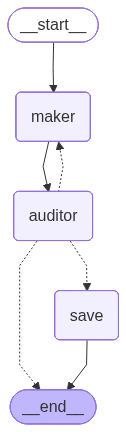

In [30]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))